<a href="https://colab.research.google.com/github/VishalB210/Carisurg_MedTech_Pathways_Portfolio/blob/main/Week_5_Interim_Submission/week5_interim_data_profiling_schema_mapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
# Week 5 Interim Submission
# Data Profiling, Schema Mapping, Complaint Grouping, and Cleaning

import os
import shutil
import zipfile

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

# Create output folders
os.makedirs("/content/figures", exist_ok=True)
os.makedirs("/content/tables", exist_ok=True)
os.makedirs("/content/data", exist_ok=True)
os.makedirs("/content/reports", exist_ok=True)

# Dataset file name
file_path = "/content/yaleemmlc_admissionprediction_triage.csv"

# If file is not already uploaded, upload it
if not os.path.exists(file_path):
    print("Please upload yaleemmlc_admissionprediction_triage.csv")
    uploaded = files.upload()

    # Use the uploaded CSV file
    uploaded_files = list(uploaded.keys())
    csv_files = [f for f in uploaded_files if f.endswith(".csv")]

    if len(csv_files) == 0:
        raise FileNotFoundError("No CSV file uploaded.")

    uploaded_csv = csv_files[0]
    file_path = f"/content/{uploaded_csv}"

# Load dataset
df = pd.read_csv(file_path)

# Rename index-like column
df = df.rename(columns={"Unnamed: 0": "original_index"})

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)
print("\nFirst 10 columns:")
print(df.columns[:10].tolist())

display(df.head())

Dataset loaded successfully.
Dataset shape: (55121, 226)

First 10 columns:
['original_index', 'dep_name', 'esi', 'age', 'gender', 'ethnicity', 'race', 'lang', 'religion', 'maritalstatus']


,original_index,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4,87,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,...,0,0,0,0,0,0,0,0,0,0
1,17,B,2,53,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,...,0,0,0,0,0,0,0,0,0,0
2,40,A,2,49,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,...,0,0,1,0,0,0,0,0,0,0
3,47,A,3,22,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,...,0,0,0,0,0,0,0,0,0,0
4,60,A,2,62,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,...,0,0,0,0,0,0,0,0,0,0


ESI target variable distribution:


,ESI Level,Count,Percent
0,1,77,0.14
1,2,17924,32.52
2,3,27010,49.00
3,4,8896,16.14
4,5,1214,2.20


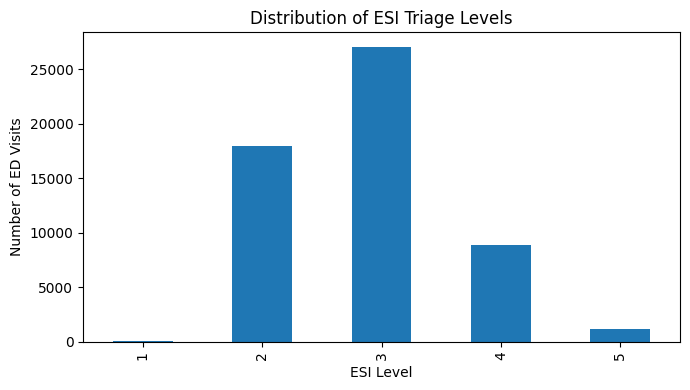

In [25]:
# Target variable profile: ESI

esi_profile = (
    df["esi"]
    .value_counts()
    .sort_index()
    .reset_index()
)

esi_profile.columns = ["ESI Level", "Count"]
esi_profile["Percent"] = round((esi_profile["Count"] / len(df)) * 100, 2)

print("ESI target variable distribution:")
display(esi_profile)

# Save table
esi_profile.to_csv("/content/tables/esi_distribution.csv", index=False)

# Plot ESI distribution
plt.figure(figsize=(7, 4))
df["esi"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of ESI Triage Levels")
plt.xlabel("ESI Level")
plt.ylabel("Number of ED Visits")
plt.tight_layout()

plt.savefig("/content/figures/esi_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [26]:
# Schema mapping: separate variables by role

target_col = "esi"

id_cols = ["original_index"]

leakage_cols = ["disposition", "previousdispo"]

demographic_cols = [
    "age", "gender", "ethnicity", "race", "lang", "religion",
    "maritalstatus", "employstatus", "insurance_status"
]

arrival_cols = [
    "dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"
]

vital_cols = [
    "triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp",
    "triage_vital_rr", "triage_vital_o2", "triage_vital_o2_device",
    "triage_vital_temp", "triage_glucose"
]

cc_cols = [col for col in df.columns if col.startswith("cc_")]

schema_rows = []

for col in df.columns:
    if col == target_col:
        role = "Target variable"
    elif col in id_cols:
        role = "Identifier / index"
    elif col in leakage_cols:
        role = "Potential leakage variable"
    elif col in demographic_cols:
        role = "Demographic feature"
    elif col in arrival_cols:
        role = "Arrival / operational feature"
    elif col in vital_cols:
        role = "Triage clinical measurement"
    elif col in cc_cols:
        role = "Chief complaint indicator"
    else:
        role = "Other"

    schema_rows.append({
        "column": col,
        "role": role,
        "dtype": str(df[col].dtype),
        "missing_count": df[col].isna().sum(),
        "missing_percent": round(df[col].isna().mean() * 100, 2),
        "unique_values": df[col].nunique()
    })

schema_df = pd.DataFrame(schema_rows)

print("Schema role counts:")
display(schema_df["role"].value_counts())

print("\nPotential leakage variables:")
display(schema_df[schema_df["role"] == "Potential leakage variable"])

print("\nTriage clinical measurement variables:")
display(schema_df[schema_df["role"] == "Triage clinical measurement"])

print("\nSchema preview:")
display(schema_df.head(30))

# Save table
schema_df.to_csv("/content/tables/schema_mapping.csv", index=False)

Schema role counts:


,count
role,
Chief complaint indicator,200
Demographic feature,9
Triage clinical measurement,8
Arrival / operational feature,5
Potential leakage variable,2
Target variable,1
Identifier / index,1



Potential leakage variables:


,column,role,dtype,missing_count,missing_percent,unique_values
12,disposition,Potential leakage variable,object,0,0.0,2
17,previousdispo,Potential leakage variable,object,0,0.0,10



Triage clinical measurement variables:


,column,role,dtype,missing_count,missing_percent,unique_values
18,triage_vital_hr,Triage clinical measurement,float64,0,0.0,279
19,triage_vital_sbp,Triage clinical measurement,float64,0,0.0,365
20,triage_vital_dbp,Triage clinical measurement,float64,0,0.0,259
21,triage_vital_rr,Triage clinical measurement,float64,0,0.0,62
22,triage_vital_o2,Triage clinical measurement,float64,0,0.0,58
23,triage_vital_o2_device,Triage clinical measurement,int64,0,0.0,2
24,triage_vital_temp,Triage clinical measurement,float64,0,0.0,188
25,triage_glucose,Triage clinical measurement,int64,0,0.0,672



Schema preview:


,column,role,dtype,missing_count,missing_percent,unique_values
0,original_index,Identifier / index,int64,0,0.0,55121
1,dep_name,Arrival / operational feature,object,0,0.0,3
2,esi,Target variable,int64,0,0.0,5
3,age,Demographic feature,int64,0,0.0,88
4,gender,Demographic feature,object,0,0.0,2
5,ethnicity,Demographic feature,object,0,0.0,4
6,race,Demographic feature,object,0,0.0,8
7,lang,Demographic feature,object,0,0.0,2
8,religion,Demographic feature,object,0,0.0,12
9,maritalstatus,Demographic feature,object,0,0.0,10


In [27]:
# Vital sign profiling

numeric_vitals = [
    "triage_vital_hr",
    "triage_vital_sbp",
    "triage_vital_dbp",
    "triage_vital_rr",
    "triage_vital_o2",
    "triage_vital_temp",
    "triage_glucose"
]

print("Vital sign summary statistics:")
vital_profile = df[numeric_vitals].describe().T.round(2)
display(vital_profile)

print("\nMedian vital signs by ESI level:")
vitals_by_esi = df.groupby("esi")[numeric_vitals].median().round(2)
display(vitals_by_esi)

# Save tables
vital_profile.to_csv("/content/tables/vital_sign_summary.csv")
vitals_by_esi.to_csv("/content/tables/vital_signs_by_esi.csv")

Vital sign summary statistics:


,count,mean,std,min,25%,50%,75%,max
triage_vital_hr,55121.0,86.45,16.96,32.0,74.0,85.0,97.0,221.0
triage_vital_sbp,55121.0,133.68,22.65,53.0,118.0,132.0,147.0,266.0
triage_vital_dbp,55121.0,79.53,14.59,27.0,70.0,79.0,89.0,189.0
triage_vital_rr,55121.0,17.84,2.07,8.0,16.0,18.0,18.0,66.0
triage_vital_o2,55121.0,97.02,2.08,62.0,96.0,98.0,98.0,99.0
triage_vital_temp,55121.0,98.09,0.81,91.5,97.7,98.0,98.4,106.0
triage_glucose,55121.0,130.09,73.66,16.0,93.0,107.0,134.0,1066.0



Median vital signs by ESI level:


,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_temp,triage_glucose
esi,,,,,,,
1,84.0,139.0,77.0,18.0,97.0,97.7,120.0
2,87.0,131.0,78.0,18.0,97.0,98.0,111.0
3,85.0,133.0,79.0,18.0,98.0,98.1,107.0
4,84.0,131.0,80.0,18.0,98.0,98.0,102.0
5,83.0,129.0,79.0,18.0,98.0,98.0,101.0


In [28]:
# Demographic and arrival variable profiling

print("Age summary:")
age_summary = df["age"].describe().round(2)
display(age_summary)

print("\nMedian age by ESI level:")
age_by_esi = df.groupby("esi")["age"].median().round(2)
display(age_by_esi)

# Save age summaries
age_summary.to_csv("/content/tables/age_summary.csv")
age_by_esi.to_csv("/content/tables/age_by_esi.csv")

# Categorical profiles
categorical_profile_tables = {}

for col in demographic_cols[1:] + arrival_cols:
    print(f"\n--- {col} ---")

    temp = df[col].value_counts(dropna=False).reset_index()
    temp.columns = [col, "count"]
    temp["percent"] = round((temp["count"] / len(df)) * 100, 2)

    categorical_profile_tables[col] = temp
    display(temp.head(10))

    temp.to_csv(f"/content/tables/{col}_profile.csv", index=False)

Age summary:


,age
count,55121.00
mean,55.32
std,19.54
min,18.00
25%,40.00
50%,55.00
75%,70.00
max,107.00



Median age by ESI level:


,age
esi,
1,70.0
2,60.0
3,54.0
4,47.0
5,46.0



--- gender ---


...

,arrivalmonth,count,percent
0,June,5987,10.86
1,May,5909,10.72
2,March,5416,9.83
3,April,5367,9.74
4,July,4616,8.37
5,August,4472,8.11
6,January,4234,7.68
7,September,4084,7.41
8,October,4037,7.32
9,December,3829,6.95



--- arrivalday ---


,arrivalday,count,percent
0,Monday,8687,15.76
1,Wednesday,8257,14.98
2,Tuesday,8179,14.84
3,Thursday,7910,14.35
4,Friday,7871,14.28
5,Sunday,7203,13.07
6,Saturday,7014,12.72



--- arrivalhour_bin ---


,arrivalhour_bin,count,percent
0,14-Nov,15872,28.79
1,15-18,13739,24.93
2,19-22,9743,17.68
3,10-Jul,9052,16.42
4,23-02,4236,7.68
5,6-Mar,2479,4.50


In [29]:
# Data quality checks

print("Original arrivalhour_bin values:")
display(df["arrivalhour_bin"].value_counts(dropna=False))

# Fix arrival hour bin labels affected by spreadsheet formatting
arrivalhour_fix = {
    "14-Nov": "11-14",
    "10-Jul": "07-10",
    "6-Mar": "03-06"
}

df["arrivalhour_bin_clean"] = df["arrivalhour_bin"].replace(arrivalhour_fix)

print("\nCleaned arrivalhour_bin values:")
display(df["arrivalhour_bin_clean"].value_counts(dropna=False))

# Check whether chief complaint columns are binary
cc_binary_check = []

for col in cc_cols:
    unique_vals = sorted(df[col].dropna().unique())
    cc_binary_check.append({
        "chief_complaint": col,
        "unique_values": unique_vals,
        "number_of_unique_values": len(unique_vals),
        "is_binary_0_1": set(unique_vals).issubset({0, 1})
    })

cc_binary_check_df = pd.DataFrame(cc_binary_check)

print("\nChief complaint columns with non-binary values:")
non_binary_cc = cc_binary_check_df[cc_binary_check_df["is_binary_0_1"] == False]
display(non_binary_cc)

print("\nNumber of non-binary chief complaint columns:", len(non_binary_cc))

# Save binary check
cc_binary_check_df.to_csv("/content/tables/chief_complaint_binary_check_before.csv", index=False)

# Convert all chief complaint columns to binary presence/absence
# Any value greater than 0 becomes 1
df_cc_binary = df.copy()
df_cc_binary[cc_cols] = (df_cc_binary[cc_cols] > 0).astype(int)

# Check after cleaning
cc_binary_check_after = []

for col in cc_cols:
    unique_vals = sorted(df_cc_binary[col].dropna().unique())
    cc_binary_check_after.append({
        "chief_complaint": col,
        "unique_values": unique_vals,
        "is_binary_0_1": set(unique_vals).issubset({0, 1})
    })

cc_binary_check_after_df = pd.DataFrame(cc_binary_check_after)

print("\nNumber of non-binary chief complaint columns after cleaning:")
display(cc_binary_check_after_df[cc_binary_check_after_df["is_binary_0_1"] == False])

cc_binary_check_after_df.to_csv("/content/tables/chief_complaint_binary_check_after.csv", index=False)

Original arrivalhour_bin values:


,count
arrivalhour_bin,
14-Nov,15872
15-18,13739
19-22,9743
10-Jul,9052
23-02,4236
6-Mar,2479



Cleaned arrivalhour_bin values:


,count
arrivalhour_bin_clean,
11-14,15872
15-18,13739
19-22,9743
07-10,9052
23-02,4236
03-06,2479



Chief complaint columns with non-binary values:


,chief_complaint,unique_values,number_of_unique_values,is_binary_0_1
2,cc_abdominalpain,"[0, 1, 2]",3,False
4,cc_abnormallab,"[0, 1, 2]",3,False
31,cc_chestpain,"[0, 1, 2]",3,False
59,cc_epistaxis,"[0, 1, 2]",3,False
71,cc_fall,"[0, 1, 2]",3,False
126,cc_medicalscreening,"[0, 1, 2]",3,False
142,cc_other,"[0, 1, 2, 3]",4,False
146,cc_palpitations,"[0, 1, 2]",3,False
185,cc_uri,"[0, 1, 2]",3,False



Number of non-binary chief complaint columns: 9

Number of non-binary chief complaint columns after cleaning:


,chief_complaint,unique_values,is_binary_0_1


Top 25 chief complaints after binary cleaning:


,chief_complaint,count,percent
2,cc_abdominalpain,6716,12.18
142,cc_other,4413,8.01
31,cc_chestpain,3711,6.73
163,cc_shortnessofbreath,3098,5.62
21,cc_backpain,1997,3.62
71,cc_fall,1924,3.49
38,cc_cough,1439,2.61
46,cc_dizziness,1292,2.34
119,cc_legpain,1264,2.29
57,cc_emesis,1249,2.27


<Figure size 1000x700 with 0 Axes>

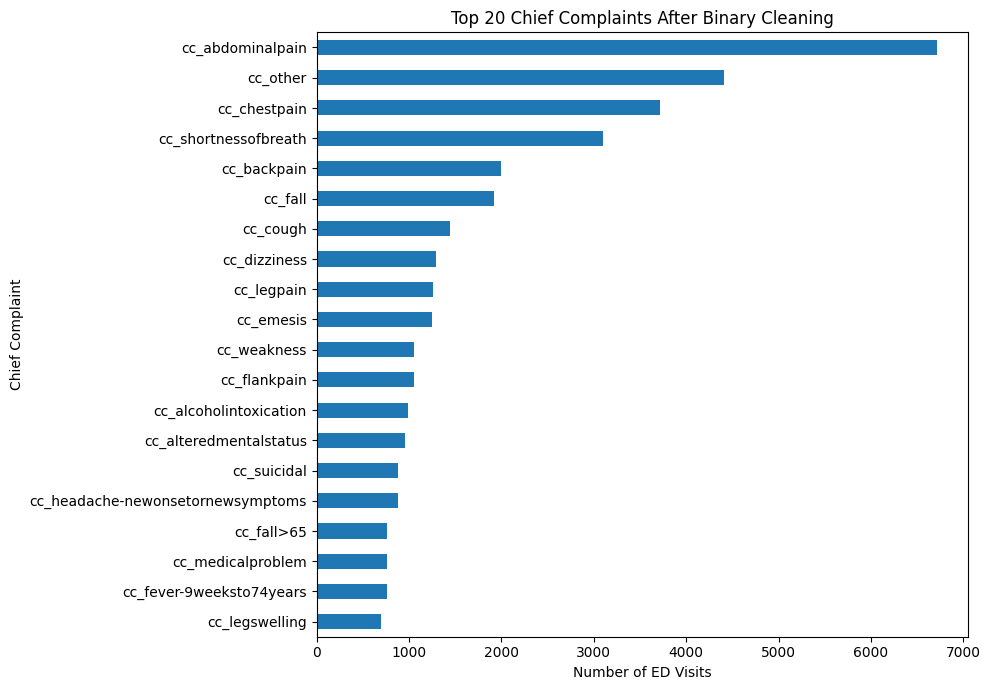

In [30]:
# Chief complaint prevalence using cleaned binary values

cc_prevalence_clean = pd.DataFrame({
    "chief_complaint": cc_cols,
    "count": df_cc_binary[cc_cols].sum().values
})

cc_prevalence_clean["percent"] = round((cc_prevalence_clean["count"] / len(df_cc_binary)) * 100, 2)
cc_prevalence_clean = cc_prevalence_clean.sort_values("count", ascending=False)

print("Top 25 chief complaints after binary cleaning:")
display(cc_prevalence_clean.head(25))

# Save table
cc_prevalence_clean.to_csv("/content/tables/chief_complaint_prevalence_clean.csv", index=False)

# Plot top 20 chief complaints
plt.figure(figsize=(10, 7))
ax = cc_prevalence_clean.head(20).sort_values("count").plot(
    x="chief_complaint",
    y="count",
    kind="barh",
    legend=False,
    figsize=(10, 7)
)

ax.set_title("Top 20 Chief Complaints After Binary Cleaning")
ax.set_xlabel("Number of ED Visits")
ax.set_ylabel("Chief Complaint")

plt.tight_layout()
plt.savefig("/content/figures/top_20_chief_complaints_clean.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
# Group chief complaints into body-system families

def map_complaint_family(col):
    name = col.replace("cc_", "").lower()

    respiratory_keywords = [
        "breath", "dyspnea", "shortnessofbreath", "respiratory", "wheezing",
        "cough", "asthma", "uri", "influenza", "sorethroat", "hemoptysis",
        "nasalcongestion", "sinus", "coldlikesymptoms"
    ]

    cardiovascular_keywords = [
        "chestpain", "chesttightness", "palpitations", "irregularheartbeat",
        "cardiacarrest", "hypertension", "hypotension", "tachycardia",
        "rapidheartrate", "syncope", "nearsyncope"
    ]

    gastrointestinal_keywords = [
        "abdominal", "epigastric", "nausea", "emesis", "diarrhea",
        "constipation", "gibleeding", "rectal", "flankpain",
        "giproblem", "dehydration"
    ]

    neurologic_keywords = [
        "alteredmentalstatus", "confusion", "dizziness", "headache",
        "migraine", "seizure", "seizures", "strokealert", "numbness",
        "weakness", "extremityweakness", "lethargy", "lossofconsciousness",
        "neurologicproblem", "unresponsive", "blurredvision"
    ]

    genitourinary_keywords = [
        "dysuria", "hematuria", "urinary", "vaginal", "pelvic",
        "testicle", "malegu", "femalegu", "std", "exposuretostd",
        "groinpain"
    ]

    musculoskeletal_trauma_keywords = [
        "injury", "pain", "swelling", "fall", "trauma", "motorvehiclecrash",
        "motorcyclecrash", "assaultvictim", "laceration", "rib", "ankle",
        "arm", "back", "elbow", "finger", "foot", "hand", "headinjury",
        "hip", "jaw", "joint", "knee", "leg", "neck", "shoulder",
        "thumb", "toe", "wrist", "facialinjury", "headlaceration",
        "faciallaceration", "extremitylaceration"
    ]

    skin_wound_infection_keywords = [
        "abscess", "cellulitis", "rash", "skin", "wound", "burn",
        "cyst", "mass", "insectbite", "animalbite", "tickremoval",
        "suture", "bruising"
    ]

    eye_ent_oral_keywords = [
        "eye", "ear", "otalgia", "conjunctivitis", "dental",
        "oral", "throat", "nasal", "sinus"
    ]

    endocrine_metabolic_keywords = [
        "bloodsugar", "hyperglycemia", "glucose", "decreasedbloodsugar"
    ]

    mental_substance_keywords = [
        "addiction", "agitation", "alcohol", "anxiety", "depression",
        "detox", "drug", "hallucinations", "homicidal", "ingestion",
        "overdose", "panicattack", "poisoning", "psychiatric",
        "psychotic", "suicidal", "withdrawal"
    ]

    general_keywords = [
        "fatigue", "fever", "chills", "medicalproblem", "medicalscreening",
        "medication", "other", "follow-up", "abnormallab"
    ]

    if any(k in name for k in respiratory_keywords):
        return "Respiratory"
    elif any(k in name for k in cardiovascular_keywords):
        return "Cardiovascular"
    elif any(k in name for k in gastrointestinal_keywords):
        return "Gastrointestinal"
    elif any(k in name for k in neurologic_keywords):
        return "Neurologic"
    elif any(k in name for k in genitourinary_keywords):
        return "Genitourinary"
    elif any(k in name for k in mental_substance_keywords):
        return "Mental health / substance / toxicology"
    elif any(k in name for k in endocrine_metabolic_keywords):
        return "Endocrine / metabolic"
    elif any(k in name for k in eye_ent_oral_keywords):
        return "Eye / ENT / oral"
    elif any(k in name for k in skin_wound_infection_keywords):
        return "Skin / wound / infection"
    elif any(k in name for k in musculoskeletal_trauma_keywords):
        return "Musculoskeletal / trauma"
    elif any(k in name for k in general_keywords):
        return "General / constitutional / other"
    else:
        return "Other / needs review"


cc_family_map = pd.DataFrame({
    "chief_complaint_column": cc_cols,
    "body_system_family": [map_complaint_family(col) for col in cc_cols]
})

print("Complaint family counts:")
display(cc_family_map["body_system_family"].value_counts())

print("\nChief complaint to family mapping:")
display(cc_family_map)

# Save mapping table
cc_family_map.to_csv("/content/tables/chief_complaint_family_mapping.csv", index=False)

Complaint family counts:


,count
body_system_family,
Musculoskeletal / trauma,51
Mental health / substance / toxicology,20
Neurologic,20
Respiratory,20
Skin / wound / infection,19
Gastrointestinal,15
Eye / ENT / oral,13
Cardiovascular,11
General / constitutional / other,10



Chief complaint to family mapping:


,chief_complaint_column,body_system_family
0,cc_abdominalcramping,Gastrointestinal
1,cc_abdominaldistention,Gastrointestinal
2,cc_abdominalpain,Gastrointestinal
3,cc_abdominalpainpregnant,Gastrointestinal
4,cc_abnormallab,General / constitutional / other
...,...,...
195,cc_woundcheck,Skin / wound / infection
196,cc_woundinfection,Skin / wound / infection
197,cc_woundre-evaluation,Skin / wound / infection
198,cc_wristinjury,Musculoskeletal / trauma


Cleaned chief complaint family prevalence:


,complaint_family,count,percent
6,family_musculoskeletal_trauma,12182,22.10
0,family_gastrointestinal,10820,19.63
7,family_respiratory,7154,12.98
1,family_general_constitutional_other,6856,12.44
5,family_neurologic,6331,11.49
8,family_cardiovascular,5359,9.72
3,family_mental_health_substance_toxicology,3913,7.10
2,family_skin_wound_infection,3150,5.71
9,family_eye_ent_oral,1937,3.51
11,family_genitourinary,1462,2.65


<Figure size 1000x600 with 0 Axes>

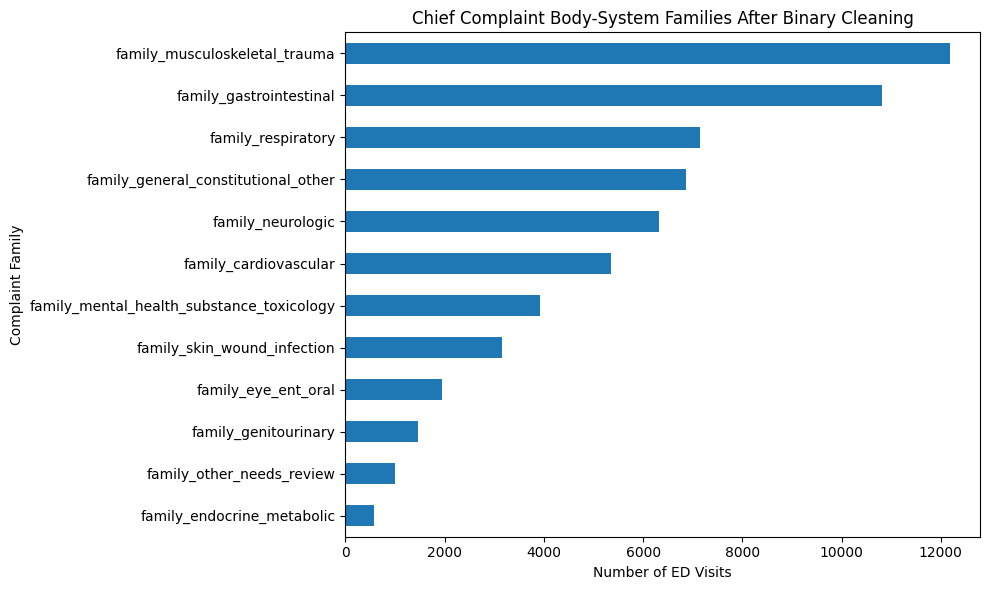

In [32]:
# Create family-level complaint columns using cleaned binary chief complaints

df_analysis = df_cc_binary.copy()

for family in cc_family_map["body_system_family"].unique():
    family_cols_for_group = cc_family_map.loc[
        cc_family_map["body_system_family"] == family,
        "chief_complaint_column"
    ].tolist()

    new_col = (
        "family_"
        + family.lower()
        .replace(" ", "_")
        .replace("/", "")
        .replace("-", "")
        .replace("__", "_")
    )

    df_analysis[new_col] = df_analysis[family_cols_for_group].max(axis=1)

family_cols = [col for col in df_analysis.columns if col.startswith("family_")]

family_prevalence_clean = pd.DataFrame({
    "complaint_family": family_cols,
    "count": df_analysis[family_cols].sum().values
})

family_prevalence_clean["percent"] = round(
    (family_prevalence_clean["count"] / len(df_analysis)) * 100, 2
)

family_prevalence_clean = family_prevalence_clean.sort_values("count", ascending=False)

print("Cleaned chief complaint family prevalence:")
display(family_prevalence_clean)

# Save table
family_prevalence_clean.to_csv("/content/tables/complaint_family_prevalence_clean.csv", index=False)

# Plot family prevalence
plt.figure(figsize=(10, 6))
ax = family_prevalence_clean.sort_values("count").plot(
    x="complaint_family",
    y="count",
    kind="barh",
    legend=False,
    figsize=(10, 6)
)

ax.set_title("Chief Complaint Body-System Families After Binary Cleaning")
ax.set_xlabel("Number of ED Visits")
ax.set_ylabel("Complaint Family")

plt.tight_layout()
plt.savefig("/content/figures/complaint_family_prevalence_clean.png", dpi=300, bbox_inches="tight")
plt.show()


Cleaned complaint family prevalence by ESI level (%):


esi,1,2,3,4,5
family_gastrointestinal,3.90,12.50,31.29,1.34,0.49
family_general_constitutional_other,11.69,11.98,12.17,12.17,27.18
family_skin_wound_infection,2.60,1.31,4.41,15.23,30.31
family_mental_health_substance_toxicology,1.30,17.84,2.31,0.80,1.57
family_other_needs_review,0.00,1.48,2.08,1.74,0.66
family_neurologic,49.35,16.97,11.58,1.21,1.15
family_musculoskeletal_trauma,11.69,10.70,20.16,51.28,20.43
family_respiratory,16.88,15.01,11.93,12.94,6.26
family_cardiovascular,12.99,18.09,7.56,0.70,0.16
family_eye_ent_oral,1.30,2.95,2.43,6.07,17.46


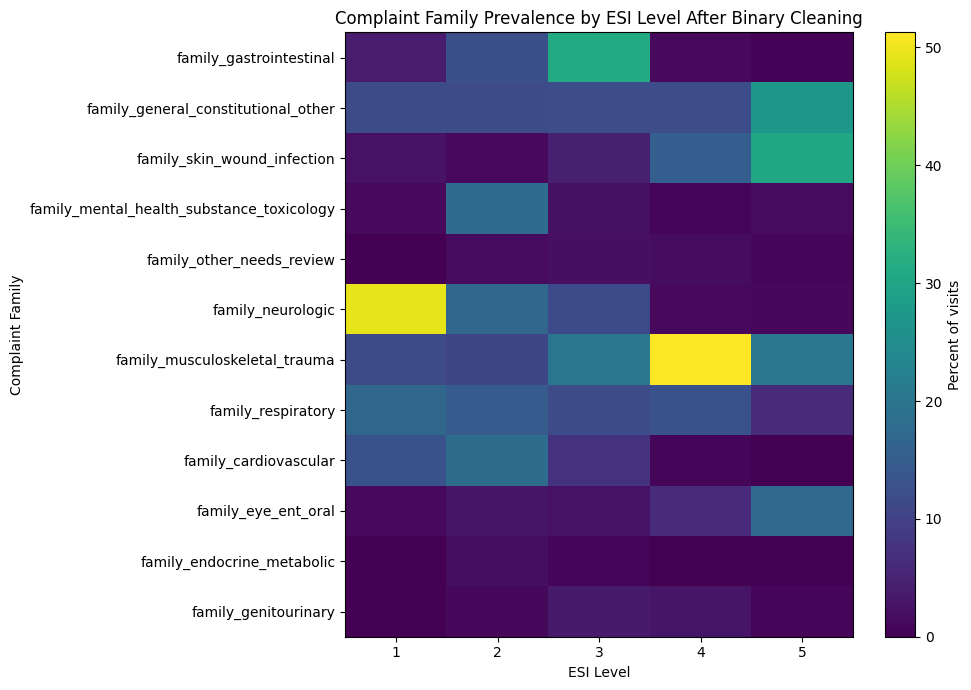

In [33]:
# Complaint family prevalence by ESI level

family_by_esi_clean = df_analysis.groupby("esi")[family_cols].mean().T * 100
family_by_esi_clean = family_by_esi_clean.round(2)

print("Cleaned complaint family prevalence by ESI level (%):")
display(family_by_esi_clean)

# Save table
family_by_esi_clean.to_csv("/content/tables/complaint_family_by_esi_clean.csv")

# Heatmap
plt.figure(figsize=(10, 7))
plt.imshow(family_by_esi_clean, aspect="auto")
plt.colorbar(label="Percent of visits")

plt.xticks(range(len(family_by_esi_clean.columns)), family_by_esi_clean.columns)
plt.yticks(range(len(family_by_esi_clean.index)), family_by_esi_clean.index)

plt.title("Complaint Family Prevalence by ESI Level After Binary Cleaning")
plt.xlabel("ESI Level")
plt.ylabel("Complaint Family")
plt.tight_layout()

plt.savefig("/content/figures/complaint_family_by_esi_heatmap_clean.png", dpi=300, bbox_inches="tight")
plt.show()

In [34]:
# Create final cleaned analysis dataset

final_df = df_analysis.copy()

# Add cleaned arrival hour bin
arrivalhour_fix = {
    "14-Nov": "11-14",
    "10-Jul": "07-10",
    "6-Mar": "03-06"
}

final_df["arrivalhour_bin_clean"] = final_df["arrivalhour_bin"].replace(arrivalhour_fix)

# Define columns to exclude from modelling
exclude_from_model = [
    "original_index",
    "esi",
    "disposition",
    "previousdispo",
    "arrivalhour_bin"
]

# Feature columns safe for modelling
feature_cols = [col for col in final_df.columns if col not in exclude_from_model]

# Save cleaned dataset
final_df.to_csv("/content/data/week5_cleaned_analysis_dataset.csv", index=False)

print("Final cleaned dataset shape:")
print(final_df.shape)

print("\nTarget variable:")
print("esi")

print("\nColumns excluded from modelling:")
print(exclude_from_model)

print("\nNumber of safe feature columns:")
print(len(feature_cols))

print("\nFirst 20 feature columns:")
print(feature_cols[:20])

Final cleaned dataset shape:
(55121, 239)

Target variable:
esi

Columns excluded from modelling:
['original_index', 'esi', 'disposition', 'previousdispo', 'arrivalhour_bin']

Number of safe feature columns:
234

First 20 feature columns:
['dep_name', 'age', 'gender', 'ethnicity', 'race', 'lang', 'religion', 'maritalstatus', 'employstatus', 'insurance_status', 'arrivalmode', 'arrivalmonth', 'arrivalday', 'triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2', 'triage_vital_o2_device', 'triage_vital_temp']


In [35]:
# Create README.md and Week 5 interim report

readme_text = """
# CariSurg Week 5 Interim Submission

## Project Overview

This Week 5 interim submission focuses on exploratory data profiling, schema mapping, chief complaint grouping, and preparation of an emergency department triage dataset for later modelling.

The dataset contains emergency department visit records with demographic information, arrival details, triage vital signs, glucose values, disposition-related columns, and chief complaint indicators.

## Dataset Summary

- Number of records: 55,121
- Original number of columns: 226
- Final cleaned analysis dataset columns: 239
- Target variable: `esi`
- Number of chief complaint columns: 200
- Number of body-system family columns created: 12

## Target Variable

The target variable is `esi`, which represents the Emergency Severity Index triage level.

ESI distribution:

| ESI Level | Count | Percent |
|---|---:|---:|
| 1 | 77 | 0.14% |
| 2 | 17,924 | 32.52% |
| 3 | 27,010 | 49.00% |
| 4 | 8,896 | 16.14% |
| 5 | 1,214 | 2.20% |

Most visits were ESI 3, followed by ESI 2 and ESI 4. ESI 1 cases were rare, representing only 0.14% of the dataset.

## Schema Mapping

The variables were grouped into the following roles:

| Variable Role | Number of Columns |
|---|---:|
| Chief complaint indicator | 200 |
| Demographic feature | 9 |
| Triage clinical measurement | 8 |
| Arrival / operational feature | 5 |
| Potential leakage variable | 2 |
| Target variable | 1 |
| Identifier / index | 1 |

The columns `disposition` and `previousdispo` were identified as potential leakage variables and were excluded from the recommended modelling feature set.

## Data Quality Notes

The `arrivalhour_bin` column contained values that appeared to be affected by spreadsheet formatting:

- `14-Nov` was corrected to `11-14`
- `10-Jul` was corrected to `07-10`
- `6-Mar` was corrected to `03-06`

Nine chief complaint columns contained values greater than 1. Since these columns represent complaint presence, all `cc_` columns were converted to binary format:

- 0 = complaint not present
- 1 = complaint present

## Vital Sign Summary

The dataset had no missing values for the triage vital sign variables.

Key vital sign observations:

- Median heart rate: 85 bpm
- Median systolic blood pressure: 132 mmHg
- Median diastolic blood pressure: 79 mmHg
- Median respiratory rate: 18 breaths/min
- Median oxygen saturation: 98%
- Median temperature: 98.0°F
- Median glucose: 107 mg/dL

Temperature was interpreted as Fahrenheit.

## Chief Complaint Findings

The most common chief complaint was abdominal pain, appearing in 6,716 visits or 12.18% of the dataset.

Top chief complaints included:

| Chief Complaint | Count | Percent |
|---|---:|---:|
| Abdominal pain | 6,716 | 12.18% |
| Other | 4,413 | 8.01% |
| Chest pain | 3,711 | 6.73% |
| Shortness of breath | 3,098 | 5.62% |
| Back pain | 1,997 | 3.62% |
| Fall | 1,924 | 3.49% |

## Body-System Complaint Families

The 200 chief complaint columns were grouped into broader body-system families to improve interpretability.

The most common complaint families were:

| Complaint Family | Count | Percent |
|---|---:|---:|
| Musculoskeletal / trauma | 12,182 | 22.10% |
| Gastrointestinal | 10,820 | 19.63% |
| Respiratory | 7,154 | 12.98% |
| General / constitutional / other | 6,856 | 12.44% |
| Neurologic | 6,331 | 11.49% |
| Cardiovascular | 5,359 | 9.72% |

## Complaint Families by ESI Level

Several clinically meaningful patterns were observed:

- Neurologic complaints were highest among ESI 1 visits at 49.35%.
- Cardiovascular complaints were highest among ESI 2 visits at 18.09%.
- Gastrointestinal complaints were highest among ESI 3 visits at 31.29%.
- Musculoskeletal / trauma complaints were highest among ESI 4 visits at 51.28%.
- Skin / wound / infection complaints were highest among ESI 5 visits at 30.31%.

ESI 1 only had 77 cases, so percentages for ESI 1 should be interpreted carefully.

## Files Included

- `week5_cleaned_analysis_dataset.csv`
- `schema_mapping.csv`
- `esi_distribution.csv`
- `vital_sign_summary.csv`
- `vital_signs_by_esi.csv`
- `chief_complaint_prevalence_clean.csv`
- `chief_complaint_family_mapping.csv`
- `complaint_family_prevalence_clean.csv`
- `complaint_family_by_esi_clean.csv`
- `esi_distribution.png`
- `top_20_chief_complaints_clean.png`
- `complaint_family_prevalence_clean.png`
- `complaint_family_by_esi_heatmap_clean.png`

## Summary

This Week 5 interim work prepared the dataset for future modelling by identifying the target variable, mapping columns into clinically meaningful roles, detecting potential leakage variables, cleaning chief complaint indicators, correcting an arrival-hour formatting issue, and grouping chief complaints into body-system families.
"""

report_text = """
# Week 5 Interim Report: Data Profiling and Schema Mapping

## Introduction

The Week 5 interim task focused on understanding the structure and clinical meaning of an emergency department triage dataset. The dataset contains 55,121 emergency department visits and 226 original columns. These include demographic variables, arrival-related variables, triage vital signs, glucose values, disposition-related information, and 200 chief complaint indicator columns.

The main target variable is `esi`, which represents the Emergency Severity Index triage level. This variable was treated as the outcome for analysis and future modelling.

## Target Variable Analysis

The ESI distribution showed that most visits were assigned ESI 3, representing 49.00% of the dataset. ESI 2 represented 32.52%, ESI 4 represented 16.14%, ESI 5 represented 2.20%, and ESI 1 represented only 0.14%.

This shows that the dataset is imbalanced. ESI 3 and ESI 2 dominate the dataset, while ESI 1 cases are rare. This is important for future modelling because a model may perform poorly on rare high-acuity cases if class imbalance is not considered.

## Schema Mapping

A schema mapping approach was used to separate the dataset into clinically meaningful groups. The dataset contained 200 chief complaint indicator columns, 9 demographic features, 8 triage clinical measurement variables, 5 arrival or operational variables, 2 potential leakage variables, 1 target variable, and 1 identifier/index column.

The columns `disposition` and `previousdispo` were identified as potential leakage variables. These should not be used as predictive model features because they may reflect patient outcomes or later clinical decisions rather than information available at the point of triage.

## Vital Sign Profiling

The triage vital sign variables included heart rate, systolic blood pressure, diastolic blood pressure, respiratory rate, oxygen saturation, oxygen device use, temperature, and glucose. These variables had no missing values in the dataset.

The median vital signs were fairly similar across ESI levels. Median heart rate was approximately 85 bpm, median systolic blood pressure was 132 mmHg, median diastolic blood pressure was 79 mmHg, median respiratory rate was 18 breaths per minute, median oxygen saturation was 98%, median temperature was approximately 98.0°F, and median glucose was 107 mg/dL.

Temperature was interpreted as Fahrenheit, which is important for correct clinical interpretation. Glucose showed a wide range from 16 to 1066, suggesting the presence of extreme values or severe clinical cases.

## Chief Complaint Cleaning

The dataset contained 200 chief complaint columns beginning with `cc_`. These columns were expected to represent complaint presence or absence. However, nine chief complaint columns contained values greater than 1. To standardise these variables, all chief complaint columns were converted to binary format, where 0 indicated the complaint was not present and 1 indicated the complaint was present.

After this cleaning step, the most common chief complaint was abdominal pain, present in 6,716 visits or 12.18% of the dataset. Other common complaints included other, chest pain, shortness of breath, back pain, fall, cough, dizziness, leg pain, emesis, weakness, and flank pain.

## Body-System Grouping

The 200 chief complaint columns were grouped into broader body-system families to improve clinical interpretability. The complaint families included musculoskeletal/trauma, gastrointestinal, respiratory, general/constitutional/other, neurologic, cardiovascular, mental health/substance/toxicology, skin/wound/infection, eye/ENT/oral, genitourinary, endocrine/metabolic, and other/needs review.

The most common complaint family was musculoskeletal/trauma, present in 12,182 visits or 22.10% of the dataset. This was followed by gastrointestinal complaints at 19.63%, respiratory complaints at 12.98%, general/constitutional/other complaints at 12.44%, neurologic complaints at 11.49%, and cardiovascular complaints at 9.72%.

## Complaint Families by ESI Level

The complaint-family analysis showed clinically meaningful variation across ESI levels. Neurologic complaints were highest in ESI 1 visits at 49.35%. Cardiovascular complaints were highest in ESI 2 visits at 18.09%. Gastrointestinal complaints were highest in ESI 3 visits at 31.29%. Musculoskeletal/trauma complaints were highest in ESI 4 visits at 51.28%. Skin/wound/infection complaints were highest in ESI 5 visits at 30.31%.

These patterns suggest that different complaint families may be associated with different levels of triage acuity. However, ESI 1 had only 77 cases, so findings for ESI 1 should be interpreted cautiously.

## Data Quality Issues

One data quality issue was identified in the `arrivalhour_bin` column. Some values appeared to have been affected by spreadsheet date formatting. The values `14-Nov`, `10-Jul`, and `6-Mar` were cleaned to `11-14`, `07-10`, and `03-06`, respectively.

Another data quality issue was the presence of non-binary values in some chief complaint columns. This was corrected by converting all chief complaint values greater than 0 to 1.

## Modelling Preparation

For future modelling, the recommended target variable is `esi`. The columns `original_index`, `disposition`, `previousdispo`, and the original `arrivalhour_bin` should be excluded from the modelling feature set. The cleaned `arrivalhour_bin_clean` column should be used instead of the original arrival hour column.

After cleaning and feature engineering, the final analysis dataset contained 55,121 rows and 239 columns. There were 234 safe feature columns after excluding the target, identifier, leakage-risk variables, and the original arrival-hour column.

## Conclusion

The Week 5 interim analysis successfully profiled the dataset, mapped variables into clinically meaningful groups, identified potential leakage variables, cleaned chief complaint indicators, corrected an arrival-hour formatting issue, and grouped chief complaints into interpretable body-system families. These steps provide a stronger foundation for future modelling and clinical interpretation of emergency department triage acuity.
"""

with open("/content/README.md", "w") as f:
    f.write(readme_text)

with open("/content/reports/week5_interim_report.md", "w") as f:
    f.write(report_text)

print("Created files:")
print("- README.md")
print("- reports/week5_interim_report.md")

Created files:
- README.md
- reports/week5_interim_report.md


In [38]:
# Create clean ZIP file for GitHub upload

submission_dir = "/content/week5_interim_submission_clean"

# Remove old folder if it exists
if os.path.exists(submission_dir):
    shutil.rmtree(submission_dir)

# Create folder structure
os.makedirs(f"{submission_dir}/figures", exist_ok=True)
os.makedirs(f"{submission_dir}/tables", exist_ok=True)
os.makedirs(f"{submission_dir}/data", exist_ok=True)
os.makedirs(f"{submission_dir}/reports", exist_ok=True)

# Copy README
shutil.copy("/content/README.md", f"{submission_dir}/README.md")

# Copy figures
for file in os.listdir("/content/figures"):
    shutil.copy(f"/content/figures/{file}", f"{submission_dir}/figures/{file}")

# Copy tables
for file in os.listdir("/content/tables"):
    shutil.copy(f"/content/tables/{file}", f"{submission_dir}/tables/{file}")

# Copy data
for file in os.listdir("/content/data"):
    shutil.copy(f"/content/data/{file}", f"{submission_dir}/data/{file}")

# Copy reports
for file in os.listdir("/content/reports"):
    shutil.copy(f"/content/reports/{file}", f"{submission_dir}/reports/{file}")

# Create ZIP
zip_path = "/content/week5_interim_submission_clean.zip"

if os.path.exists(zip_path):
    os.remove(zip_path)

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files_in_folder in os.walk(submission_dir):
        for file in files_in_folder:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, submission_dir)
            zipf.write(file_path, arcname)

print("Created clean ZIP file:")
print(zip_path)

Created clean ZIP file:
/content/week5_interim_submission_clean.zip


In [39]:
from google.colab import files

files.download("/content/week5_interim_submission_clean.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>